<a href="https://colab.research.google.com/github/khushi-2003/AI-projects/blob/main/PowerEnergyPrediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Power plant project

Step 1 - Data import

In [49]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/khushi-2003/Datasets/refs/heads/main/PowerPlant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [51]:
df.shape

(9568, 5)

In [52]:
df.duplicated().sum()

np.int64(41)

In [53]:
df = df.drop_duplicates()

In [47]:
df.duplicated().sum()

np.int64(0)

Step 2 - Seperate x and y features.

  y : PE


In [55]:
x = df.drop(columns='PE')
y = df[['PE']]

In [56]:
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [57]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


Step 3 - Feature Engineering


In [58]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = make_pipeline(
    SimpleImputer(strategy = 'mean'),
    StandardScaler()
).set_output(transform='pandas')

In [59]:
x_pre = num_pipe.fit_transform(x)
x_pre.head()

,AT,V,AP,RH
0,-1.520448,-1.066041,-0.403535,1.141599
1,0.534897,0.330813,-0.309262,0.059223
2,1.354348,0.205475,-1.024725,-2.151400
3,-0.079020,-0.362884,-1.012941,0.236538
4,-1.055645,-1.074713,0.655349,1.633837


Step 4 - Split training and testing data


In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pre,y,train_size=0.75,random_state=21)

Step 5 - Model Building

In [61]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import EarlyStopping

#initialise the model
model = Sequential()

#input layer
model.add(Input(shape=(x_train.shape[1],)))

#add the hidden layer 1
model.add(Dense(units=32,activation='relu'))


# Hidden layer2
model.add(Dense(units=16,activation='relu'))



#Output layer
model.add(Dense(units=1,activation='linear'))

In [62]:
model.compile(optimizer='adam',loss='mse',metrics =['accuracy'])

In [63]:
nn=model.fit(x_train,y_train,validation_split=0.2,epochs=200)

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0000e+00 - loss: 201829.5312 - val_accuracy: 0.0000e+00 - val_loss: 191133.4688
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 154462.3281 - val_accuracy: 0.0000e+00 - val_loss: 105182.9375
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 58933.1055 - val_accuracy: 0.0000e+00 - val_loss: 26707.0195
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 19962.7480 - val_accuracy: 0.0000e+00 - val_loss: 15097.5127
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 13265.5830 - val_accuracy: 0.0000e+00 - val_loss: 10267.7764
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 8789.4951 - val_accuracy: 0.0000e+00 - val_loss: 6557.0835
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 5425.8032 - val_accuracy: 0.0000e+00 - val_

Step 6 - Learning curve

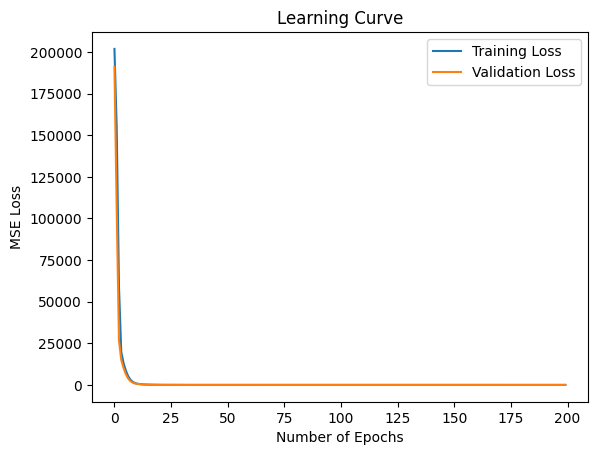

In [64]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Step 7 - Model Evaluation

In [65]:
model.evaluate(x_train,y_train)

224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0000e+00 - loss: 18.9579


[18.957889556884766, 0.0]

In [66]:
model.evaluate(x_test,y_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0000e+00 - loss: 18.2903


[18.290264129638672, 0.0]

In [67]:
yprobs = model.predict(x_test)
yprobs[:5]


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[448.25626],
       [448.88754],
       [462.67734],
       [465.9622 ],
       [463.51736]], dtype=float32)

In [69]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.callbacks import EarlyStopping

#initialise the model
model_dropout = Sequential()

#input layer
model_dropout.add(Input(shape=(x_train.shape[1],)))

#add the hidden layer 1
model_dropout.add(Dense(units=32,activation='relu'))

#add dropout
model_dropout.add(Dropout(rate=0.3))

# Hidden layer2
model_dropout.add(Dense(units=16,activation='relu'))

#Dropout layer
model_dropout.add(Dropout(rate=0.15))

#Output layer
model_dropout.add(Dense(units=1,activation='linear'))

In [71]:
model_dropout.compile(optimizer='adam',loss='mse',metrics =['accuracy'])

In [72]:
es = EarlyStopping(monitor='val_loss',patience=10)


In [74]:
nn_dropout = model_dropout.fit(x_train,y_train,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0000e+00 - loss: 200124.9062 - val_accuracy: 0.0000e+00 - val_loss: 185359.0312
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 140058.4375 - val_accuracy: 0.0000e+00 - val_loss: 83221.4297
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 47391.2734 - val_accuracy: 0.0000e+00 - val_loss: 20458.6895
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 22801.6367 - val_accuracy: 0.0000e+00 - val_loss: 12042.9629
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 17516.4043 - val_accuracy: 0.0000e+00 - val_loss: 7764.7012
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 13473.9473 - val_accuracy: 0.0000e+00 - val_loss: 4915.9180
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 11127.9521 - val_accuracy: 0.0000e+00 - val_

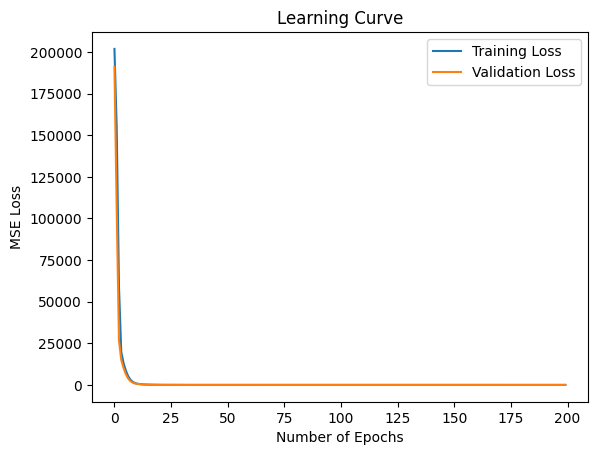

In [75]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [77]:
model.evaluate(x_train,y_train)

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 18.9579


[18.957889556884766, 0.0]

In [79]:
from keras.layers import BatchNormalization

In [81]:
# Intialize the model
model_bn= Sequential()

# Add the Input layer
model_bn.add(Input(shape=(x_train.shape[1],)))

# Add the Hidden layer 1
model_bn.add(Dense(units=32,activation='relu'))

# Add the BatchNormalization
model_bn.add(BatchNormalization())

# Add the Hidden layer2
model_bn.add(Dense(units=16,activation='relu'))

# Add the BatchNormalization
model_bn.add(BatchNormalization())

# Add the Output layer
model_bn.add(Dense(units=1,activation='linear'))


model_bn.compile(optimizer='adam',loss='mse',metrics=['accuracy'])


In [82]:
es = EarlyStopping(monitor='val_loss',patience=10)


nn_bn=model.fit(x_train,y_train,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 18.4558 - val_accuracy: 0.0000e+00 - val_loss: 18.5967
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.7387 - val_accuracy: 0.0000e+00 - val_loss: 19.1247
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.6734 - val_accuracy: 0.0000e+00 - val_loss: 20.9202
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.8734 - val_accuracy: 0.0000e+00 - val_loss: 19.0488
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.8269 - val_accuracy: 0.0000e+00 - val_loss: 19.1329
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.6688 - val_accuracy: 0.0000e+00 - val_loss: 18.8738
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.7142 - val_accuracy: 0.0000e+00 - val_loss: 18.8555
Epoch 8/200
179/179 ━━━━━━━

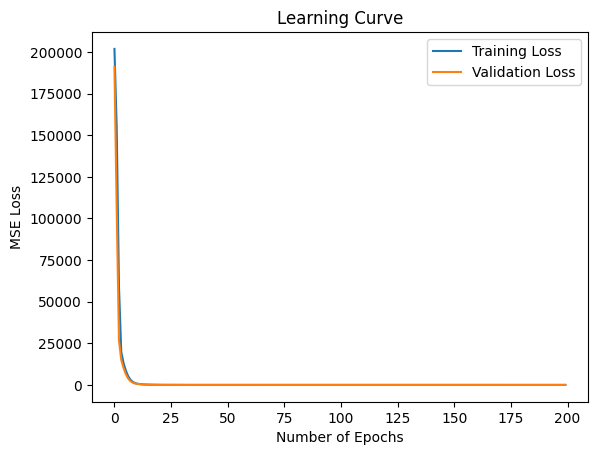

In [83]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [84]:
model_bn.evaluate(x_test,y_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 206678.2969


[206678.296875, 0.0]

In [85]:
model.evaluate(x_train,y_train)

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 18.9050


[18.905040740966797, 0.0]